# <span style="color:green">Prof. Glen Nwaila and Dr. Steven Zhang
</span>

# <span style="color:blue">Practical 2: Matrix Geospatial Data
</span>

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Matrix Data

In [53]:
# What is matrix data? Let's borrow and modify an example from - https://matplotlib.org/stable/gallery/images_contours_and_fields/layer_images.html#sphx-glr-gallery-images-contours-and-fields-layer-images-py

# Let's define a function over two axes - (x and y)

def func3(x, y):
    output = (np.sin(x)**2+np.sin(y)**2) * np.exp(-(x**2 + y**2))
    return output


In [54]:
# Let's make a grid

# make these smaller to increase the resolution
dx, dy = 0.05, 0.05


x = np.arange(-3.0, 3.0, dx)
y = np.arange(-3.0, 3.0, dy)



X, Y = np.meshgrid(x, y)

In [55]:
X


array([[-3.  , -2.95, -2.9 , ...,  2.85,  2.9 ,  2.95],
       [-3.  , -2.95, -2.9 , ...,  2.85,  2.9 ,  2.95],
       [-3.  , -2.95, -2.9 , ...,  2.85,  2.9 ,  2.95],
       ...,
       [-3.  , -2.95, -2.9 , ...,  2.85,  2.9 ,  2.95],
       [-3.  , -2.95, -2.9 , ...,  2.85,  2.9 ,  2.95],
       [-3.  , -2.95, -2.9 , ...,  2.85,  2.9 ,  2.95]])

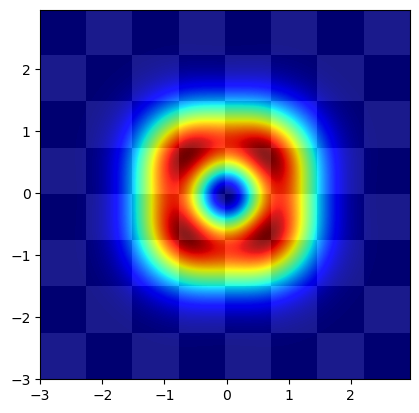

In [56]:
# Now let's run the function over the grid and see what happens



# when layering multiple images, the images need to have the same
# extent.  This does not mean they need to have the same shape, but
# they both need to render to the same coordinate system determined by
# xmin, xmax, ymin, ymax.  Note if you use different interpolations
# for the images their apparent extent could be different due to
# interpolation edge effects

extent = np.min(x), np.max(x), np.min(y), np.max(y)



fig = plt.figure(frameon=False)

Z1 = np.add.outer(range(8), range(8)) % 2  # chessboard

im1 = plt.imshow(Z1, cmap=plt.cm.gray, interpolation='nearest',
                 extent=extent)

Z2 = func3(X, Y)

im2 = plt.imshow(Z2, cmap=plt.cm.jet, alpha=.9, interpolation='bilinear',
                 extent=extent)

plt.show()

In [57]:
# Let's check the shape of these objects
Z2.shape

(120, 120)

In [58]:
# So the images are 120 pixels by 120 pixels. How did this happen?

x = np.arange(-3.0, 3.0, dx)
y = np.arange(-3.0, 3.0, dy)
len(x), len(y)

(120, 120)

In [61]:
# So the grid spacing is set by the np.arange command, which generated an array of all the linear stops of the grid.
# We can set them to whatever we want

x = np.arange(-3, 3, dx/2)
y = np.arange(-3, 3, dy/2)
X, Y = np.meshgrid(x, y)


In [62]:
X.shape

(240, 240)

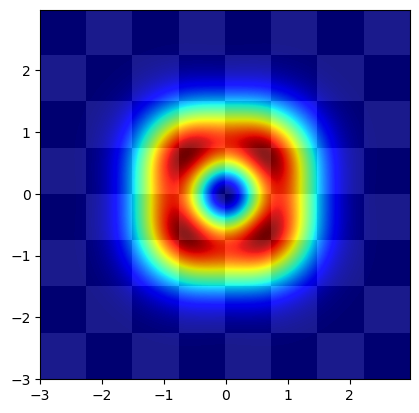

In [63]:
X, Y = np.meshgrid(x, y)

extent = np.min(x), np.max(x), np.min(y), np.max(y)
fig = plt.figure(frameon=False)

Z1 = np.add.outer(range(8), range(8)) % 2  # chessboard
im1 = plt.imshow(Z1, cmap=plt.cm.gray, interpolation='nearest',
                 extent=extent)

Z2 = func3(X, Y)

im2 = plt.imshow(Z2, cmap=plt.cm.jet, alpha=.9, interpolation='bilinear',
                 extent=extent)

plt.show()

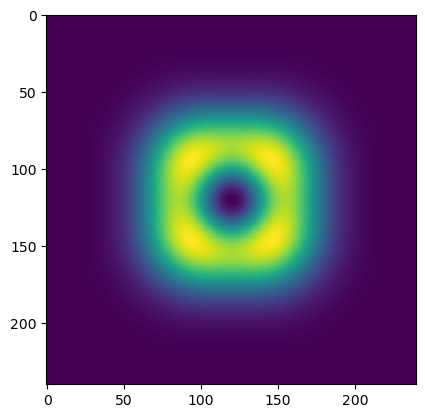

In [64]:
plt.imshow(Z2)

In [65]:
# Notice that the data is in a format that is two-dimensional? In fact, it could be in any number of dimensions.

dz = 0.05

x = np.arange(-3.0, 3.0, dx)
y = np.arange(-3.0, 3.0, dy)
z = np.arange(-3.0, 3.0, dz)

X, Y, Z = np.meshgrid(x, y, z)

In [12]:
# You can install a new package and test it out this way without having to permanenetly install it.
%pip install mayavi

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [66]:
from mayavi import mlab

x = np.linspace(-3,3,200)
y = np.linspace(-3,3,200)
z = np.linspace(-3,3,200)

X, Y, Z = np.meshgrid(x, y, z)

s = (np.sin(X**2)+np.sin(Y**2)+np.cos(Z**2)) * np.exp(-(x**2 + y**2 + z**2))

mlab.pipeline.volume(mlab.pipeline.scalar_field(s))
mlab.axes()
mlab.show()

In [67]:
# Matrix data is basically data that is multiply dimensioned and looks like a multi-dimensional matrix

# We can convert between matrix and tabular if we desire


In [68]:
Z2


array([[6.06605728e-10, 8.38420552e-10, 1.15199335e-09, ...,
        1.56992419e-09, 1.15199335e-09, 8.38420552e-10],
       [8.38420552e-10, 1.12918498e-09, 1.51813376e-09, ...,
        2.03196056e-09, 1.51813376e-09, 1.12918498e-09],
       [1.15199335e-09, 1.51813376e-09, 2.00249636e-09, ...,
        2.63664320e-09, 2.00249636e-09, 1.51813376e-09],
       ...,
       [1.56992419e-09, 2.03196056e-09, 2.63664320e-09, ...,
        3.42132297e-09, 2.63664320e-09, 2.03196056e-09],
       [1.15199335e-09, 1.51813376e-09, 2.00249636e-09, ...,
        2.63664320e-09, 2.00249636e-09, 1.51813376e-09],
       [8.38420552e-10, 1.12918498e-09, 1.51813376e-09, ...,
        2.03196056e-09, 1.51813376e-09, 1.12918498e-09]])

In [69]:
# Let's first convert the Z2 matrix into a dataframe. 
# The data is cast into a dataframe literally - the row and columns are like the coordinates before.
Z2_df = pd.DataFrame(Z2)
Z2_df

,0,1,2,3,4,5,6,7,8,9,...,230,231,232,233,234,235,236,237,238,239
0,6.066057e-10,8.384206e-10,1.151993e-09,1.569924e-09,2.119814e-09,2.835153e-09,3.756334e-09,4.931797e-09,6.419315e-09,8.287435e-09,...,1.061709e-08,8.287435e-09,6.419315e-09,4.931797e-09,3.756334e-09,2.835153e-09,2.119814e-09,1.569924e-09,1.151993e-09,8.384206e-10
1,8.384206e-10,1.129185e-09,1.518134e-09,2.031961e-09,2.703222e-09,3.571378e-09,4.683971e-09,6.097964e-09,7.881244e-09,1.011430e-08,...,1.289211e-08,1.011430e-08,7.881244e-09,6.097964e-09,4.683971e-09,3.571378e-09,2.703222e-09,2.031961e-09,1.518134e-09,1.129185e-09
2,1.151993e-09,1.518134e-09,2.002496e-09,2.636643e-09,3.459012e-09,4.516129e-09,5.863990e-09,7.569618e-09,9.712817e-09,1.238814e-08,...,1.570706e-08,1.238814e-08,9.712817e-09,7.569618e-09,5.863990e-09,4.516129e-09,3.459012e-09,2.636643e-09,2.002496e-09,1.518134e-09
3,1.569924e-09,2.031961e-09,2.636643e-09,3.421323e-09,4.431414e-09,5.721811e-09,7.358497e-09,9.420365e-09,1.200126e-08,1.521227e-08,...,1.918428e-08,1.521227e-08,1.200126e-08,9.420365e-09,7.358497e-09,5.721811e-09,4.431414e-09,3.421323e-09,2.636643e-09,2.031961e-09
4,2.119814e-09,2.703222e-09,3.459012e-09,4.431414e-09,5.674117e-09,7.251917e-09,9.242598e-09,1.173905e-08,1.485166e-08,1.871096e-08,...,2.347064e-08,1.871096e-08,1.485166e-08,1.173905e-08,9.242598e-09,7.251917e-09,5.674117e-09,4.431414e-09,3.459012e-09,2.703222e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,2.835153e-09,3.571378e-09,4.516129e-09,5.721811e-09,7.251917e-09,9.182957e-09,1.160665e-08,1.463238e-08,1.839000e-08,2.303291e-08,...,2.874156e-08,2.303291e-08,1.839000e-08,1.463238e-08,1.160665e-08,9.182957e-09,7.251917e-09,5.721811e-09,4.516129e-09,3.571378e-09
236,2.119814e-09,2.703222e-09,3.459012e-09,4.431414e-09,5.674117e-09,7.251917e-09,9.242598e-09,1.173905e-08,1.485166e-08,1.871096e-08,...,2.347064e-08,1.871096e-08,1.485166e-08,1.173905e-08,9.242598e-09,7.251917e-09,5.674117e-09,4.431414e-09,3.459012e-09,2.703222e-09
237,1.569924e-09,2.031961e-09,2.636643e-09,3.421323e-09,4.431414e-09,5.721811e-09,7.358497e-09,9.420365e-09,1.200126e-08,1.521227e-08,...,1.918428e-08,1.521227e-08,1.200126e-08,9.420365e-09,7.358497e-09,5.721811e-09,4.431414e-09,3.421323e-09,2.636643e-09,2.031961e-09
238,1.151993e-09,1.518134e-09,2.002496e-09,2.636643e-09,3.459012e-09,4.516129e-09,5.863990e-09,7.569618e-09,9.712817e-09,1.238814e-08,...,1.570706e-08,1.238814e-08,9.712817e-09,7.569618e-09,5.863990e-09,4.516129e-09,3.459012e-09,2.636643e-09,2.002496e-09,1.518134e-09


In [70]:
# This format isn't how tabular data should look like - there are no keys or attributes. 
# We can't easily plot it or do analysis on it.

# Let's reshape the dataframe structure to make it tabular.
Z2_df = Z2_df.stack().reset_index()
Z2_df

,level_0,level_1,0
0,0,0,6.066057e-10
1,0,1,8.384206e-10
2,0,2,1.151993e-09
3,0,3,1.569924e-09
4,0,4,2.119814e-09
...,...,...,...
57595,239,235,3.571378e-09
57596,239,236,2.703222e-09
57597,239,237,2.031961e-09
57598,239,238,1.518134e-09


In [71]:
# Now let's add proper column labels. 
# Notice we don't have any real primary keys, although the combination of "x" and "y" uniquely identifies each "value".
Z2_df.columns = ['x', 'y', 'value']
Z2_df

,x,y,value
0,0,0,6.066057e-10
1,0,1,8.384206e-10
2,0,2,1.151993e-09
3,0,3,1.569924e-09
4,0,4,2.119814e-09
...,...,...,...
57595,239,235,3.571378e-09
57596,239,236,2.703222e-09
57597,239,237,2.031961e-09
57598,239,238,1.518134e-09


In [72]:
Z2_df['x']

0          0
1          0
2          0
3          0
4          0
        ... 
57595    239
57596    239
57597    239
57598    239
57599    239
Name: x, Length: 57600, dtype: int64

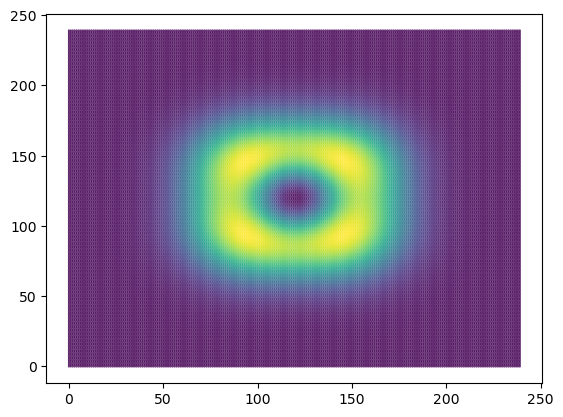

In [82]:
# We can also plot this the old way.
plt.scatter(Z2_df.x, Z2_df.y, c = Z2_df.value, cmap = 'viridis', s = 0.2)

In [83]:
# Notice that the x-y coordinates are now in pixel values or cell indices instead of the original range.
# We can fix this. Every pixel corresponds with the original range at a ratio with an offset.

conversion_ratio_x = (max(Z2_df.x)-min(Z2_df.x))/(max(x) - min(x))
offset_x = (max(x) - min(x))/2


conversion_ratio_y = (max(Z2_df.y)-min(Z2_df.y))/(max(y) - min(y))
offset_y = (max(y) - min(y))/2

In [84]:
Z2_df.x = Z2_df.x/conversion_ratio_x - offset_x
Z2_df.y = Z2_df.y/conversion_ratio_y - offset_y

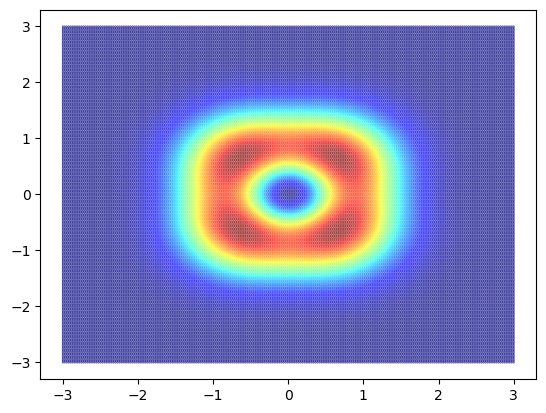

In [85]:
# Let's check again visually. 

plt.scatter(Z2_df.x, Z2_df.y, c = Z2_df.value, cmap = 
            'jet', s = 0.1)

In [86]:
Z2_df

,x,y,value
0,-3.0,-3.000000,6.066057e-10
1,-3.0,-2.974895,8.384206e-10
2,-3.0,-2.949791,1.151993e-09
3,-3.0,-2.924686,1.569924e-09
4,-3.0,-2.899582,2.119814e-09
...,...,...,...
57595,3.0,2.899582,3.571378e-09
57596,3.0,2.924686,2.703222e-09
57597,3.0,2.949791,2.031961e-09
57598,3.0,2.974895,1.518134e-09


In [26]:
# This looks pretty good now. 

In [87]:
# There should be the same number of records in both matrix and tabular format

len(Z2_df), Z2.size

(57600, 57600)

### From Gridded Data to Non-Gridded Data and Back

In [88]:
# What is gridded data? Let's explore using Z2_df.
Z2_df.sample(100)

,x,y,value
42659,1.443515,1.493724,0.029353
47279,1.920502,3.000000,0.000004
39257,1.092050,0.439331,0.248029
24102,-0.489540,-0.439331,0.266527
53600,2.598326,-0.991632,0.000484
...,...,...,...
49116,2.121339,0.916318,0.007347
764,-2.924686,-1.895397,0.000005
55822,2.824268,0.564854,0.000112
54834,2.723849,-0.138075,0.000137


In [93]:
sampled_Z2_df = Z2_df.sample(1000)

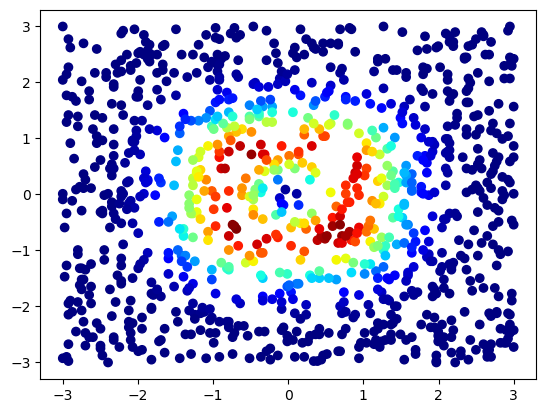

In [94]:
# Let's visualize it
plt.scatter(sampled_Z2_df.x, sampled_Z2_df.y, c = sampled_Z2_df.value, cmap = 'jet')

In [95]:
# So this data looks randomly sampled from the original Z2_df and the effect of the regularized grid is gone.

# Let's grid this data and see if we can make it gridded again.
from scipy import interpolate

x = np.arange(min(sampled_Z2_df.x), max(sampled_Z2_df.x), dx)
y = np.arange(min(sampled_Z2_df.y), max(sampled_Z2_df.y), dy)



X, Y = np.meshgrid(x, y)

new_grid = interpolate.griddata((sampled_Z2_df.x, sampled_Z2_df.y), sampled_Z2_df.value, (X, Y), method='cubic')

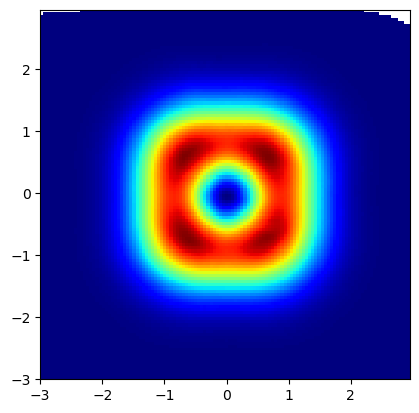

In [96]:
# Let's see what it looks like
extent = np.min(x), np.max(x), np.min(y), np.max(y)

plt.imshow(new_grid, extent = extent, cmap = 'jet')

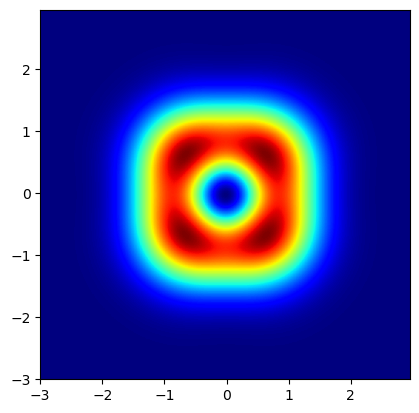

In [97]:
plt.imshow(Z2, extent = extent, cmap = 'jet')

In [110]:
# Not bad, looks like the original mostly. Let's try lowering the sampling rate.
sampled_Z2_df = Z2_df.sample(100)

x = np.arange(min(sampled_Z2_df.x), max(sampled_Z2_df.x), dx)
y = np.arange(min(sampled_Z2_df.y), max(sampled_Z2_df.y), dy)
X, Y = np.meshgrid(x, y)

new_grid = interpolate.griddata((sampled_Z2_df.x, sampled_Z2_df.y), sampled_Z2_df.value, (X, Y), method='cubic')

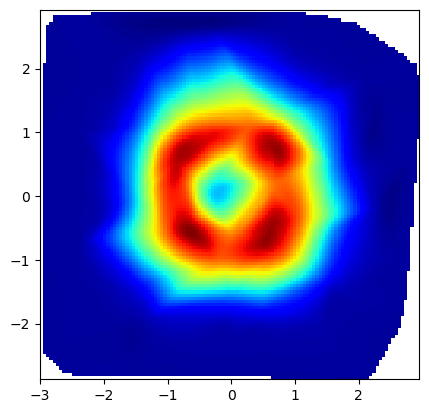

In [111]:
# Let's see what it looks like
extent = np.min(x), np.max(x), np.min(y), np.max(y)

plt.imshow(new_grid, extent = extent, cmap = 'jet')

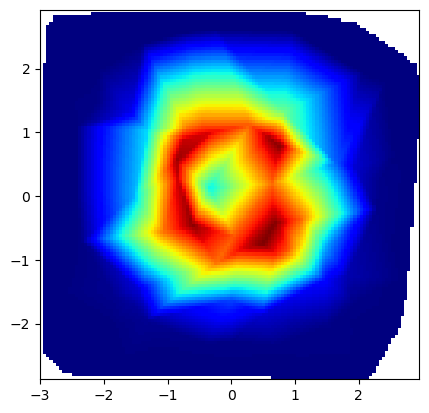

In [112]:
# What happens if we change the interpolation method?
new_grid = interpolate.griddata((sampled_Z2_df.x, sampled_Z2_df.y), sampled_Z2_df.value, (X, Y), method='linear')


extent = np.min(x), np.max(x), np.min(y), np.max(y)

plt.imshow(new_grid, extent = extent, cmap = 'jet')

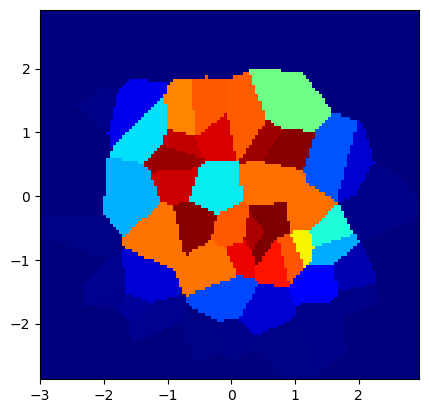

In [115]:
# What happens if we change the interpolation method?
new_grid = interpolate.griddata((sampled_Z2_df.x, sampled_Z2_df.y), sampled_Z2_df.value, (X, Y), method='nearest')
extent = np.min(x), np.max(x), np.min(y), np.max(y)

plt.imshow(new_grid, extent = extent, cmap = 'jet')

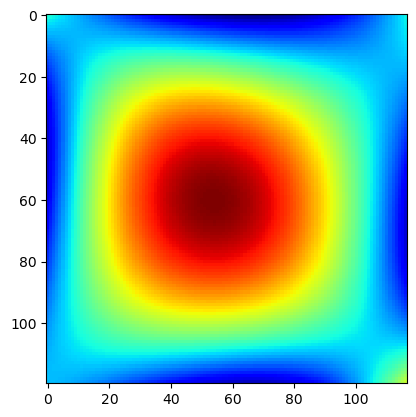

In [118]:
# Other interpolators are available - here is a spline-based interpolator
tck = interpolate.bisplrep(sampled_Z2_df.x, sampled_Z2_df.y, sampled_Z2_df.value, s=3)
new_grid = interpolate.bisplev(x, y, tck)


plt.imshow(new_grid, cmap = 'jet')
plt.show()


In [119]:
# There is a very flexible interpolator that uses the radial basis function as a kernel.
# It is thematically very similar to kriging.

from scipy.interpolate import Rbf

rbf = Rbf(sampled_Z2_df.x, sampled_Z2_df.y, sampled_Z2_df.value, epsilon=2)

Zi = rbf(X, Y)

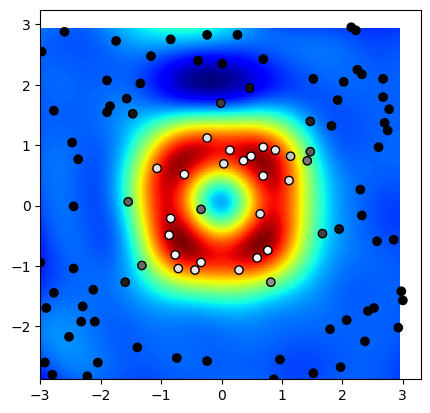

In [123]:
plt.imshow(Zi, cmap = 'jet', extent = extent)
plt.scatter(sampled_Z2_df.x, sampled_Z2_df.y, c = sampled_Z2_df.value, cmap = 'Greys_r', edgecolor = 'k')